# Sousse Mobility Study — Notebook 02


- Dataset: 230 survey responses, KK → Beb Bhar corridor


Author: Mariem Belaid | Sousse, Tunisia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
import xgboost as xgb
import shap

print("All libraries loaded ✓")


All libraries loaded ✓


In [2]:

df = pd.read_csv('Mobility_survey2.csv')
df.head()
print(df.shape)
print(df.columns.tolist())


(230, 12)
['Timestamp', 'station', 'distination', 'frequency', 'time_slot', 'wait_time', 'case    ', 'worst_day', 'use_bus', 'why_taxi_over_bus', 'worst_time_place', 'solution']


In [3]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Timestamp', 'station', 'distination', 'frequency', 'time_slot', 'wait_time', 'case', 'worst_day', 'use_bus', 'why_taxi_over_bus', 'worst_time_place', 'solution']


In [4]:
print(df.isnull().sum())

Timestamp             0
station               0
distination           0
frequency             0
time_slot             0
wait_time             0
case                  0
worst_day             0
use_bus               0
why_taxi_over_bus    58
worst_time_place     58
solution             79
dtype: int64


In [5]:
df['case_full']      = df['case'].str.contains('ممتلئ', na=False).astype(int)
df['case_wrongline'] = df['case'].str.contains('سهلول', na=False).astype(int)
df['case_nogap']     = df['case'].str.contains('لا يمر', na=False).astype(int)
df['case_rush']      = df['case'].str.contains('يتدافعون', na=False).astype(int)

print("Case 1 - Full louage:  ", df['case_full'].sum(), "/ 230")
print("Case 2 - Wrong line:   ", df['case_wrongline'].sum(), "/ 230")
print("Case 3 - No supply:    ", df['case_nogap'].sum(), "/ 230")
print("Case 4 - Rush/left:    ", df['case_rush'].sum(), "/ 230")

Case 1 - Full louage:   156 / 230
Case 2 - Wrong line:    38 / 230
Case 3 - No supply:     41 / 230
Case 4 - Rush/left:     154 / 230


In [6]:
zone_map = {

    '(la poste) البريد  القلعة الكبرى': 'Kalaa_Kebira',
    'معهد علي بورقيبة القلعة الكبرى': 'Kalaa_Kebira',
    'سير عويتي القلعة الكبرى': 'Kalaa_Kebira',
    'المراح القلعة الكبرى': 'Kalaa_Kebira',
    'الحي الجديد (مخبزة زايد) القلعة الكبرى': 'Kalaa_Kebira',

    'الوردة أكودة': 'Akouda',
    'قمعون أكودة': 'Akouda',

    'مفترق موبلاتكس حمام سوسة': 'Sousse_City',
    'سيدي سالم حمام سوسة': 'Sousse_City',
    'المنشية حمام سوسة': 'Sousse_City',

    'خزامة': 'Sousse_City',
    'مفترق بانوراما': 'Sousse_City',
    'محطة مستشفى فرحات حشاد': 'Sousse_City',
    'باب بحر': 'Sousse_City',
}

df['zone'] = df['station'].map(zone_map)

print(df['zone'].value_counts())
print("\nUnmapped stations:", df[df['zone'].isnull()]['station'].unique())

zone
Kalaa_Kebira    175
Akouda           20
Sousse_City      13
Name: count, dtype: int64

Unmapped stations: ['مفترق حنبعل أكودة' 'دردور القلعة الكبرى']


In [7]:

extra_map = {
    'مفترق حنبعل أكودة': 'Akouda',
    'دردور القلعة الكبرى': 'Kalaa_Kebira',
}

df['zone'] = df['zone'].fillna(df['station'].map(extra_map))

print(df['zone'].value_counts())
print("Total mapped:", df['zone'].notnull().sum())
print("Unmapped:", df['zone'].isnull().sum())

zone
Kalaa_Kebira    196
Akouda           21
Sousse_City      13
Name: count, dtype: int64
Total mapped: 230
Unmapped: 0


##  Exploratory Data Analysis (EDA)
*6 charts — wait distribution, failure cases, zone, time slot, worst day, co-occurrence*

In [8]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

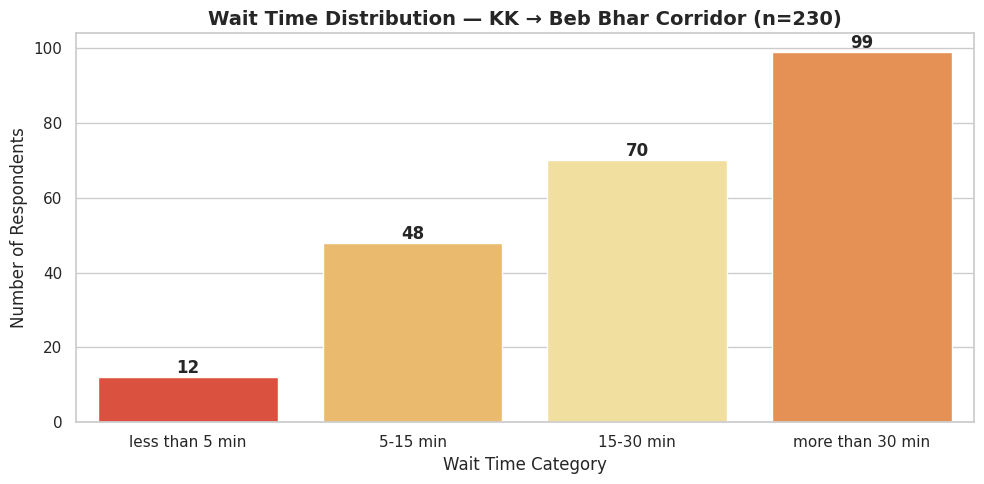

In [9]:

wait_order = ['less than 5 min', '5-15 min', '15-30 min', 'more than 30 min']

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='wait_time', order=wait_order,
                   hue='wait_time', palette='YlOrRd', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Wait Time Distribution — KK → Beb Bhar Corridor (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Wait Time Category')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.savefig('chart1_wait_distribution.png', dpi=150)
plt.show()

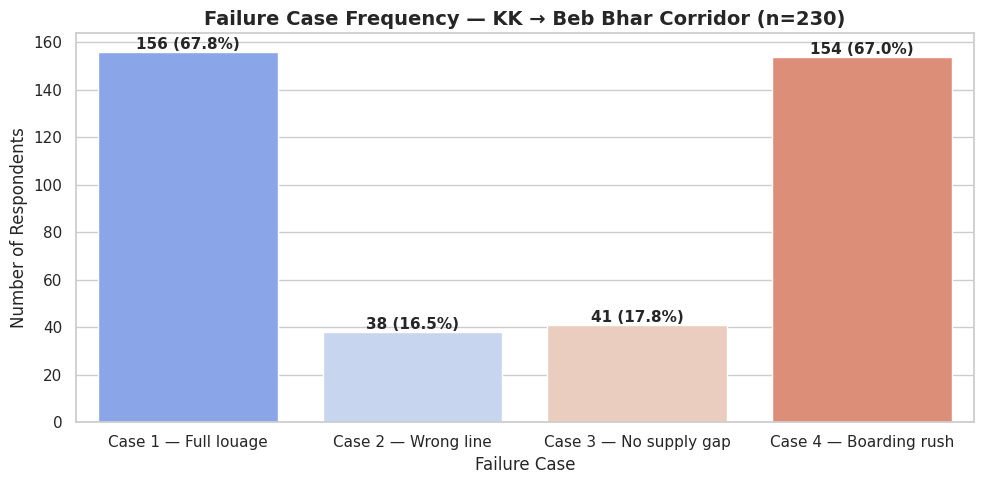

In [10]:

cases = pd.DataFrame({
    'Case': ['Case 1 — Full louage', 'Case 2 — Wrong line',
             'Case 3 — No supply gap', 'Case 4 — Boarding rush'],
    'Count': [df['case_full'].sum(), df['case_wrongline'].sum(),
              df['case_nogap'].sum(), df['case_rush'].sum()],
})
cases['Percentage'] = (cases['Count'] / 230 * 100).round(1)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cases, x='Case', y='Count',
                 hue='Case', palette='coolwarm', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({cases.loc[cases["Count"]==int(p.get_height()), "Percentage"].values[0]}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Failure Case Frequency — KK → Beb Bhar Corridor (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Failure Case')
plt.ylabel('Number of Respondents')
plt.xticks(wrap=True)
plt.tight_layout()
plt.savefig('chart2_failure_cases.png', dpi=150)
plt.show()

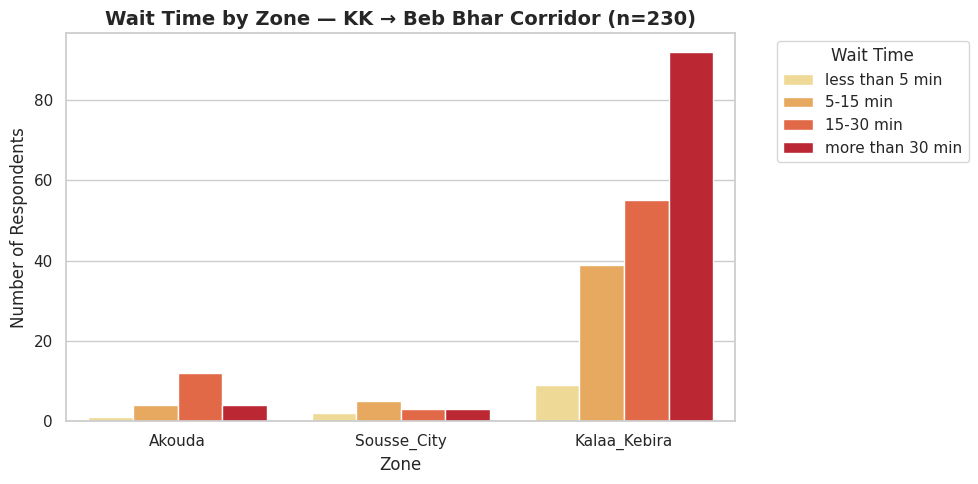

In [11]:
wait_order = ['less than 5 min', '5-15 min', '15-30 min', 'more than 30 min']

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='zone', hue='wait_time',
                   hue_order=wait_order, palette='YlOrRd')

plt.title('Wait Time by Zone — KK → Beb Bhar Corridor (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Zone')
plt.ylabel('Number of Respondents')
plt.legend(title='Wait Time', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart3_wait_by_zone.png', dpi=150)
plt.show()

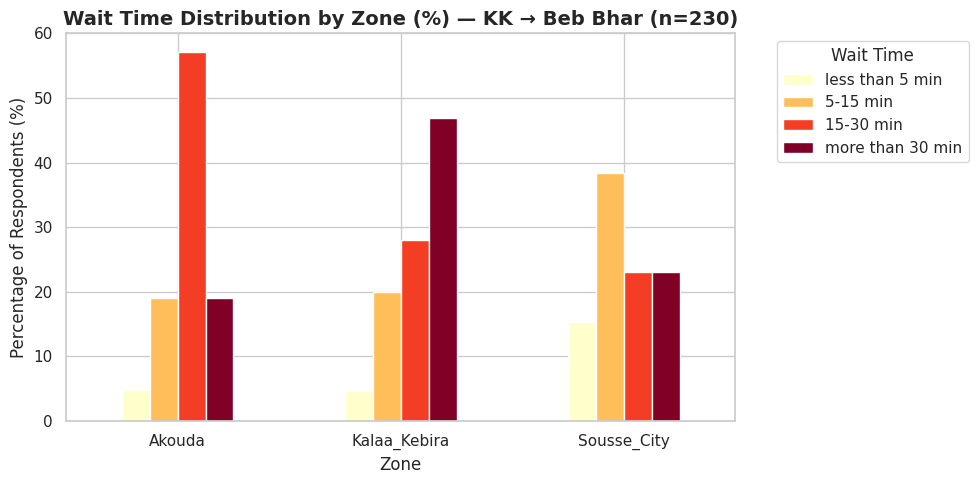

In [12]:

zone_wait = df.groupby(['zone', 'wait_time']).size().unstack(fill_value=0)
zone_wait_pct = zone_wait.div(zone_wait.sum(axis=1), axis=0) * 100
zone_wait_pct = zone_wait_pct[wait_order]

zone_wait_pct.plot(kind='bar', figsize=(10, 5),
                   colormap='YlOrRd', edgecolor='white')

plt.title('Wait Time Distribution by Zone (%) — KK → Beb Bhar (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Zone')
plt.ylabel('Percentage of Respondents (%)')
plt.legend(title='Wait Time', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_wait_by_zone_pct.png', dpi=150)
plt.show()

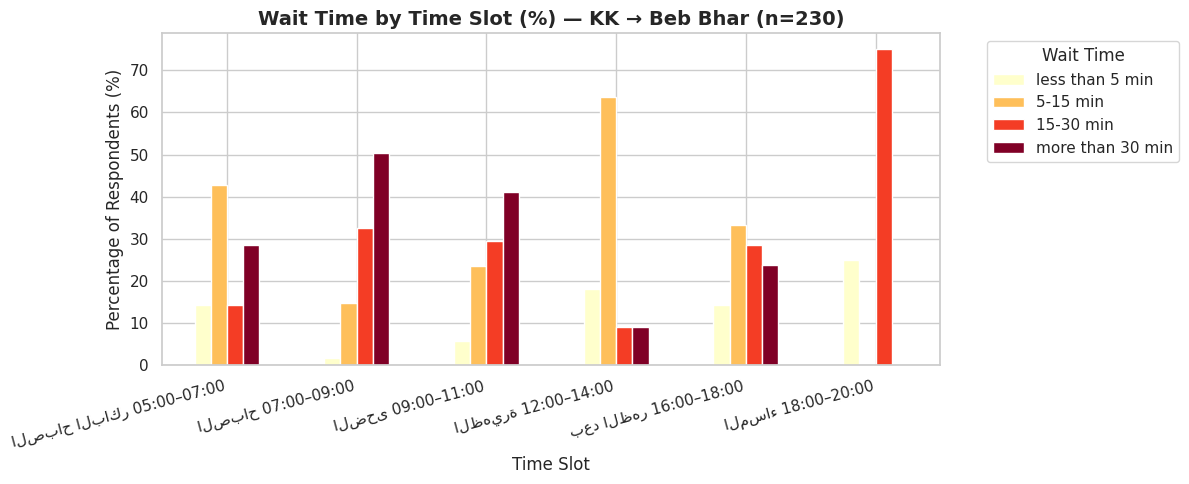

In [13]:
time_order = ['الصباح الباكر 05:00–07:00', 'الصباح 07:00–09:00',
              'الضحى 09:00–11:00', 'الظهيرة 12:00–14:00',
              'بعد الظهر 16:00–18:00', 'المساء 18:00–20:00']


time_wait = df.groupby(['time_slot', 'wait_time']).size().unstack(fill_value=0)
time_wait_pct = time_wait.div(time_wait.sum(axis=1), axis=0) * 100
time_wait_pct = time_wait_pct.reindex(time_order)[wait_order]

time_wait_pct.plot(kind='bar', figsize=(12, 5),
                   colormap='YlOrRd', edgecolor='white')

plt.title('Wait Time by Time Slot (%) — KK → Beb Bhar (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Time Slot')
plt.ylabel('Percentage of Respondents (%)')
plt.legend(title='Wait Time', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('chart4_wait_by_timeslot.png', dpi=150)
plt.show()

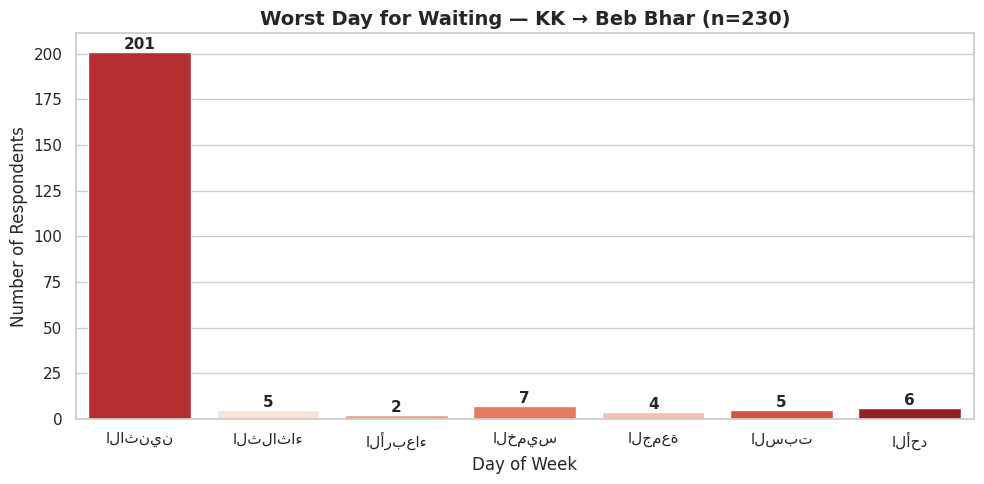

In [14]:
day_order = ['الاثنين', 'الثلاثاء', 'الأربعاء', 'الخميس',
             'الجمعة', 'السبت', 'الأحد']

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='worst_day', order=day_order,
                   hue='worst_day', palette='Reds_r', legend=False)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Worst Day for Waiting — KK → Beb Bhar (n=230)',
          fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.savefig('chart5_worst_day.png', dpi=150)
plt.show()

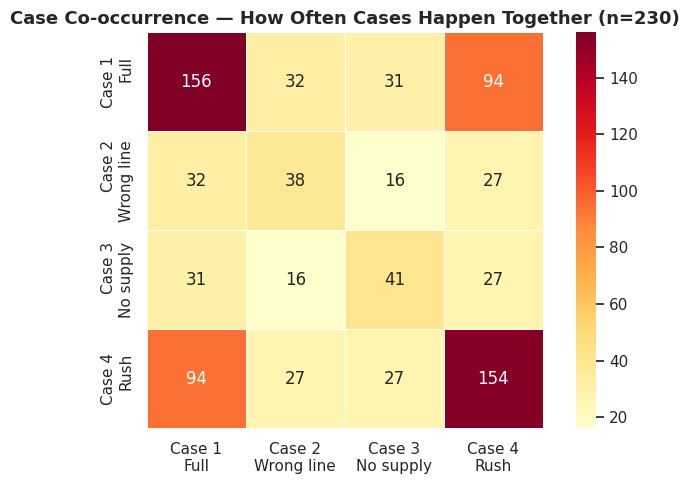

In [15]:
cases_df = df[['case_full', 'case_wrongline', 'case_nogap', 'case_rush']]
cases_df.columns = ['Case 1\nFull', 'Case 2\nWrong line',
                    'Case 3\nNo supply', 'Case 4\nRush']

co_occurrence = cases_df.T.dot(cases_df)

plt.figure(figsize=(7, 5))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, square=True)

plt.title('Case Co-occurrence — How Often Cases Happen Together (n=230)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_case_cooccurrence.png', dpi=150)
plt.show()

##  Feature Engineering & Encoding
*Prepare X and y for modelling*

In [18]:

df = df[df['wait_time'] != 'أكثر من 30 دقيقة']


df['wait_time_enc'] = le_wait.fit_transform(df['wait_time'])

print("New shape:", df.shape)
print(df['wait_time'].value_counts())

New shape: (229, 21)
wait_time
more than 30 min    99
15-30 min           70
5-15 min            48
less than 5 min     12
Name: count, dtype: int64


In [17]:
le_zone  = LabelEncoder()
le_time  = LabelEncoder()
le_freq  = LabelEncoder()
le_wait  = LabelEncoder()

df['zone_enc']      = le_zone.fit_transform(df['zone'])
df['time_slot_enc'] = le_time.fit_transform(df['time_slot'])
df['frequency_enc'] = le_freq.fit_transform(df['frequency'])
df['wait_time_enc'] = le_wait.fit_transform(df['wait_time'])

X = df[['zone_enc', 'time_slot_enc', 'frequency_enc']]
y = df['wait_time_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features (X):", X.shape)
print("Target (y):", y.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nWait time encoding:")
for label, code in zip(le_wait.classes_, range(len(le_wait.classes_))):
    print(f"  {code} = {label}")


Features (X): (229, 3)
Target (y): (229,)
Training set: (183, 3)
Test set: (46, 3)

Wait time encoding:
  0 = 15-30 min
  1 = 5-15 min
  2 = less than 5 min
  3 = more than 30 min


In [21]:
print(df['wait_time'].value_counts())
print(df['wait_time_enc'].value_counts())

wait_time
more than 30 min    99
15-30 min           70
5-15 min            48
less than 5 min     12
Name: count, dtype: int64
wait_time_enc
3    99
0    70
1    48
2    12
Name: count, dtype: int64


##  Model Training & Evaluation
*Decision Tree, Random Forest, XGBoost*

In [22]:
models = {
    'Decision Tree':  DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':        xgb.XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss')
}

baseline = y_test.value_counts(normalize=True).max()
print(f"Baseline (majority class): {baseline:.2%}\n")
print(f"{'Model':<20} {'Accuracy':>10} {'F1 (weighted)':>15} {'Beats Baseline':>15}")
print("-" * 65)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    beat = "yes" if acc > baseline else "no"
    print(f"{name:<20} {acc:>10.2%} {f1:>15.2%} {beat:>15}")
    results[name] = {'model': model, 'preds': y_pred, 'acc': acc, 'f1': f1}

print("-" * 65)

Baseline (majority class): 43.48%

Model                  Accuracy   F1 (weighted)  Beats Baseline
-----------------------------------------------------------------
Decision Tree            45.65%          42.63%             yes
Random Forest            41.30%          35.95%              no
XGBoost                  41.30%          35.95%              no
-----------------------------------------------------------------


Decision Tree — Full Report:
                  precision    recall  f1-score   support

       15-30 min       0.30      0.21      0.25        14
        5-15 min       0.50      0.40      0.44        10
 less than 5 min       0.00      0.00      0.00         2
more than 30 min       0.50      0.70      0.58        20

        accuracy                           0.46        46
       macro avg       0.33      0.33      0.32        46
    weighted avg       0.42      0.46      0.43        46



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


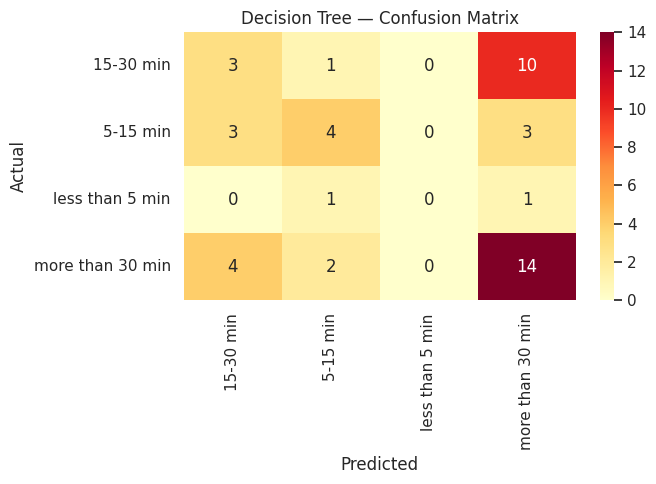

In [23]:
best_model = results['Decision Tree']['model']
y_pred_best = results['Decision Tree']['preds']

print("Decision Tree — Full Report:")
print(classification_report(y_test, y_pred_best,
      target_names=le_wait.classes_))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le_wait.classes_,
            yticklabels=le_wait.classes_)
plt.title('Decision Tree — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('chart7_confusion_matrix.png', dpi=150)
plt.show()

In [24]:
X = df[['zone_enc', 'time_slot_enc', 'frequency_enc']]
y_binary = df['case_full']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

baseline_b = y_test_b.value_counts(normalize=True).max()
print(f"Baseline (majority class): {baseline_b:.2%}\n")
print(f"{'Model':<20} {'Accuracy':>10} {'F1 (weighted)':>15} {'Beats Baseline':>15}")
print("-" * 65)

models_b = {
    'Decision Tree':  DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':        xgb.XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss')
}

results_b = {}
for name, model in models_b.items():
    model.fit(X_train_b, y_train_b)
    y_pred = model.predict(X_test_b)
    acc = accuracy_score(y_test_b, y_pred)
    f1  = f1_score(y_test_b, y_pred, average='weighted')
    beat = "yess" if acc > baseline_b else "noo"
    print(f"{name:<20} {acc:>10.2%} {f1:>15.2%} {beat:>15}")
    results_b[name] = {'model': model, 'preds': y_pred, 'acc': acc, 'f1': f1}

print("-" * 65)

Baseline (majority class): 67.39%

Model                  Accuracy   F1 (weighted)  Beats Baseline
-----------------------------------------------------------------
Decision Tree            67.39%          54.26%             noo
Random Forest            69.57%          59.05%            yess
XGBoost                  69.57%          59.05%            yess
-----------------------------------------------------------------


Random Forest — Binary Classification Report (Case 1):
              precision    recall  f1-score   support

Not Full (0)       1.00      0.07      0.12        15
    Full (1)       0.69      1.00      0.82        31

    accuracy                           0.70        46
   macro avg       0.84      0.53      0.47        46
weighted avg       0.79      0.70      0.59        46



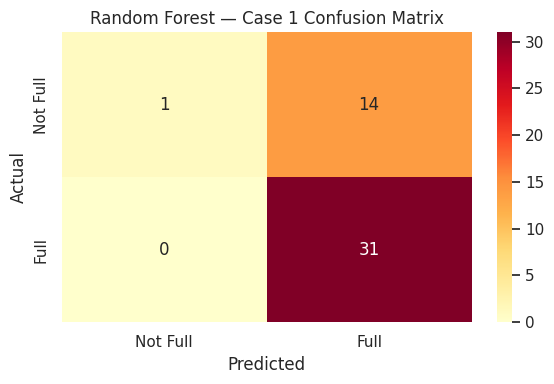

In [25]:
best_b = results_b['Random Forest']['model']
y_pred_best_b = results_b['Random Forest']['preds']

print("Random Forest — Binary Classification Report (Case 1):")
print(classification_report(y_test_b, y_pred_best_b,
      target_names=['Not Full (0)', 'Full (1)']))


cm_b = confusion_matrix(y_test_b, y_pred_best_b)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Not Full', 'Full'],
            yticklabels=['Not Full', 'Full'])
plt.title('Random Forest — Case 1 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('chart8_rf_confusion_matrix.png', dpi=150)
plt.show()

## Model Explainability (SHAP)

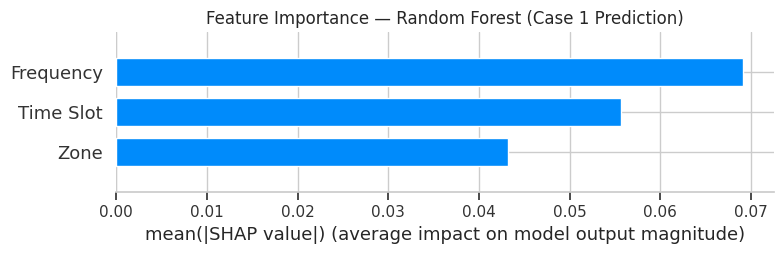

In [26]:
explainer = shap.TreeExplainer(best_b)
shap_values = explainer.shap_values(X_test_b)

plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test_b,
                  feature_names=['Zone', 'Time Slot', 'Frequency'],
                  plot_type='bar', show=False)
plt.title('Feature Importance — Random Forest (Case 1 Prediction)')
plt.tight_layout()
plt.savefig('chart9_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Simulation & Scenario Testing
*Model-based scenario analysis — predicting outcomes under different conditions*

In [27]:
import itertools
import warnings
warnings.filterwarnings('ignore')

# senario 1: Find the worst predicted commute


zones      = sorted(df['zone_enc'].unique())
timeslots  = sorted(df['time_slot_enc'].unique())
freqs      = sorted(df['frequency_enc'].unique())


combinations = list(itertools.product(zones, timeslots, freqs))
scenario_df  = pd.DataFrame(combinations,
                             columns=['zone_enc', 'time_slot_enc', 'frequency_enc'])


from sklearn.ensemble import RandomForestClassifier

X = df[['zone_enc', 'time_slot_enc', 'frequency_enc']]

rf_wait = RandomForestClassifier(n_estimators=100, random_state=42)
rf_wait.fit(X, df['wait_time_enc'])


rf_case1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_case1.fit(X, df['case_full'])


scenario_df['predicted_wait_enc']  = rf_wait.predict(scenario_df)
scenario_df['predicted_wait']      = le_wait.inverse_transform(
                                      scenario_df['predicted_wait_enc'])
scenario_df['case1_probability']   = rf_case1.predict_proba(scenario_df[
                                      ['zone_enc','time_slot_enc','frequency_enc']])[:,1]

scenario_df['zone']      = le_zone.inverse_transform(scenario_df['zone_enc'])
scenario_df['time_slot'] = le_time.inverse_transform(scenario_df['time_slot_enc'])
scenario_df['frequency'] = le_freq.inverse_transform(scenario_df['frequency_enc'])

worst = scenario_df.sort_values('case1_probability', ascending=False)
print("TOP 10 WORST PREDICTED COMMUTE PROFILES:")
print(worst[['zone', 'time_slot', 'frequency',
             'predicted_wait', 'case1_probability']].head(10).to_string(index=False))

TOP 10 WORST PREDICTED COMMUTE PROFILES:
        zone             time_slot    frequency  predicted_wait  case1_probability
 Sousse_City     الضحى 09:00–11:00 مرة أو مرتين       15-30 min           0.996667
Kalaa_Kebira بعد الظهر 16:00–18:00 مرة أو مرتين        5-15 min           0.993333
      Akouda     الضحى 09:00–11:00 3 الى 5 مرات less than 5 min           0.990000
      Akouda بعد الظهر 16:00–18:00 مرة أو مرتين       15-30 min           0.983333
      Akouda    الصباح 07:00–09:00 3 الى 5 مرات       15-30 min           0.982209
      Akouda     الضحى 09:00–11:00 مرة أو مرتين       15-30 min           0.970167
      Akouda   الظهيرة 12:00–14:00 مرة أو مرتين        5-15 min           0.969333
Kalaa_Kebira     الضحى 09:00–11:00 3 الى 5 مرات       15-30 min           0.959127
 Sousse_City    الصباح 07:00–09:00       كل يوم        5-15 min           0.952501
 Sousse_City    الصباح 07:00–09:00 مرة أو مرتين less than 5 min           0.949930


***`The highest-risk passenger profile on the KK → Beb Bhar corridor is an Akouda boarding passenger travelling during the 09:00–11:00 or 16:00–18:00 slots, facing a 97-99% probability of encountering at least one full louage during their wait.`***

In [28]:
# senario 2: Time shift intervention
# Question: if a daily KK commuter shifts from morning to midday
# how much does their predicted Case 1 probability drop?


profile_before = pd.DataFrame([{
    'zone_enc':      le_zone.transform(['Kalaa_Kebira'])[0],
    'time_slot_enc': le_time.transform(['الصباح 07:00–09:00'])[0],
    'frequency_enc': le_freq.transform(['كل يوم'])[0]
}])

profile_after = pd.DataFrame([{
    'zone_enc':      le_zone.transform(['Kalaa_Kebira'])[0],
    'time_slot_enc': le_time.transform(['الظهيرة 12:00–14:00'])[0],
    'frequency_enc': le_freq.transform(['كل يوم'])[0]
}])


prob_before = rf_case1.predict_proba(profile_before)[0][1]
prob_after  = rf_case1.predict_proba(profile_after)[0][1]
wait_before = le_wait.inverse_transform(rf_wait.predict(profile_before))[0]
wait_after  = le_wait.inverse_transform(rf_wait.predict(profile_after))[0]

print("──time shift intervention ──────────────────────────────")
print(f"Profile: Daily commuter, Kalaa Kebira\n")
print(f"BEFORE (07:00–09:00):")
print(f"  Predicted wait:          {wait_before}")
print(f"  Case 1 probability:      {prob_before:.1%}")
print(f"\nAFTER shift to midday (12:00–14:00):")
print(f"  Predicted wait:          {wait_after}")
print(f"  Case 1 probability:      {prob_after:.1%}")
print(f"\nImprovement:")
print(f"  Case 1 risk reduction:   {(prob_before - prob_after):.1%}")

──time shift intervention ──────────────────────────────
Profile: Daily commuter, Kalaa Kebira

BEFORE (07:00–09:00):
  Predicted wait:          more than 30 min
  Case 1 probability:      59.8%

AFTER shift to midday (12:00–14:00):
  Predicted wait:          5-15 min
  Case 1 probability:      53.7%

Improvement:
  Case 1 risk reduction:   6.2%


***`Even shifting commute time to the optimal midday window only reduces Case 1 risk by 6.2% for Kalaa Kebira passengers, confirming that time-shifting alone is insufficient. The root cause — inadequate supply relative to demand at origin — requires structural intervention: additional louages pre-positioned at KK during peak hours, or regulated departure intervals.`***



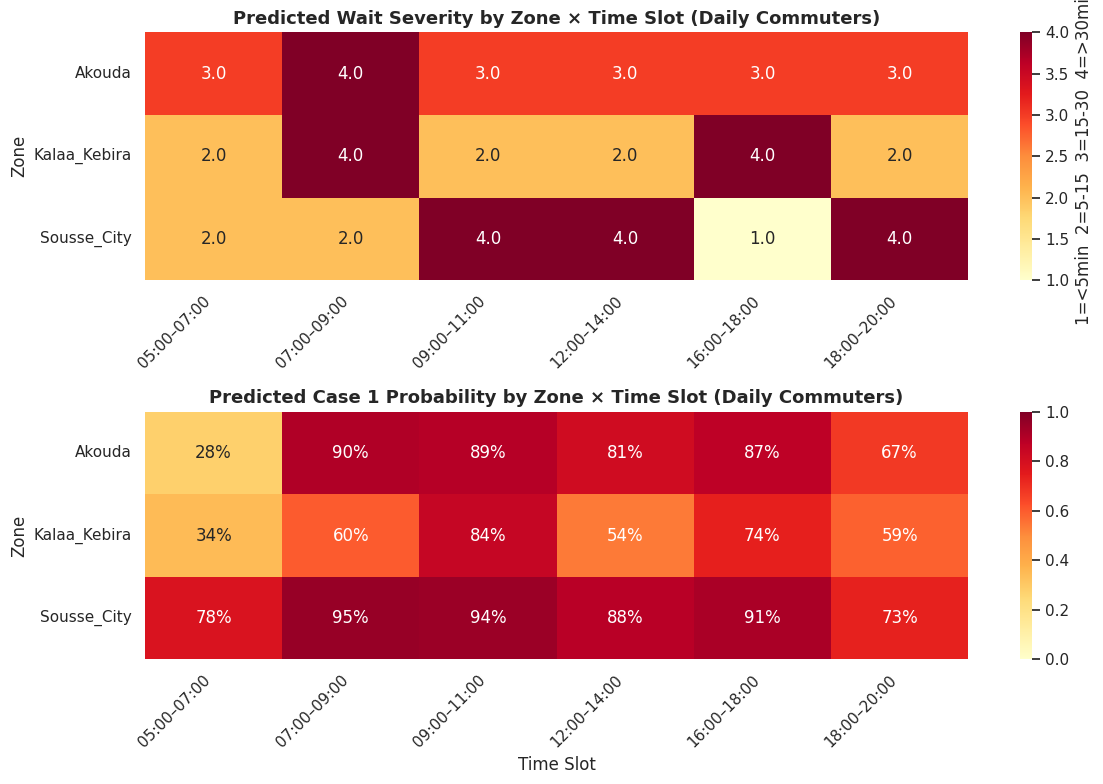

In [29]:
# senario 3: Full corridor predicted heatmap

wait_severity = {
    'less than 5 min': 1,
    '5-15 min': 2,
    '15-30 min': 3,
    'more than 30 min': 4
}
scenario_df['severity_score'] = scenario_df['predicted_wait'].map(wait_severity)


daily_mask = scenario_df['frequency'] == 'كل يوم'
heatmap_df = scenario_df[daily_mask].copy()


time_labels_clean = [
    '05:00–07:00', '07:00–09:00', '09:00–11:00',
    '12:00–14:00', '16:00–18:00', '18:00–20:00'
]


time_arabic = [
    'الصباح الباكر 05:00–07:00',
    'الصباح 07:00–09:00',
    'الضحى 09:00–11:00',
    'الظهيرة 12:00–14:00',
    'بعد الظهر 16:00–18:00',
    'المساء 18:00–20:00'
]


arabic_to_clean = dict(zip(time_arabic, time_labels_clean))


heatmap_df['time_slot_clean'] = heatmap_df['time_slot'].map(arabic_to_clean)


pivot_wait = heatmap_df.pivot_table(
    values='severity_score',
    index='zone',
    columns='time_slot_clean',
    aggfunc='mean'
)[time_labels_clean]

pivot_case1 = heatmap_df.pivot_table(
    values='case1_probability',
    index='zone',
    columns='time_slot_clean',
    aggfunc='mean'
)[time_labels_clean]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

sns.heatmap(pivot_wait, annot=True, fmt='.1f', cmap='YlOrRd',
            vmin=1, vmax=4, ax=ax1,
            cbar_kws={'label': '1=<5min  2=5-15  3=15-30  4=>30min'})
ax1.set_title('Predicted Wait Severity by Zone × Time Slot (Daily Commuters)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Zone')
ax1.set_xticklabels(time_labels_clean, rotation=45, ha='right')

sns.heatmap(pivot_case1, annot=True, fmt='.0%', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax2)
ax2.set_title('Predicted Case 1 Probability by Zone × Time Slot (Daily Commuters)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Slot')
ax2.set_ylabel('Zone')
ax2.set_xticklabels(time_labels_clean, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart10_corridor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

***`Sousse City passengers face 73–95% Case 1 probability regardless of time slot — the highest and most consistent exposure on the entire corridor. This confirms that pre-positioning at least one louage to start its journey from mid-route stations (Akouda or Hammam Sousse) rather than KK would have the highest corridor-wide impact.`***

In [30]:

print("use_bus values:", df['use_bus'].value_counts())

use_bus values: use_bus
نادراً         97
نعم أحياناً    76
لا  أبداً      56
Name: count, dtype: int64


── WAIT TIME DISTRIBUTION BY BUS USAGE ─────────────────
wait_time           less than 5 min  5-15 min  15-30 min  more than 30 min
bus_usage                                                                 
Never uses bus                  7.1      26.8       32.1              33.9
Rarely uses bus                 5.2      20.6       26.8              47.4
Uses bus sometimes              3.9      17.1       34.2              44.7

── CASE 1 RATE BY BUS USAGE ─────────────────────────────
                    Case 1 Rate  Count
bus_usage                             
Never uses bus             71.4     56
Rarely uses bus            63.9     97
Uses bus sometimes         69.7     76


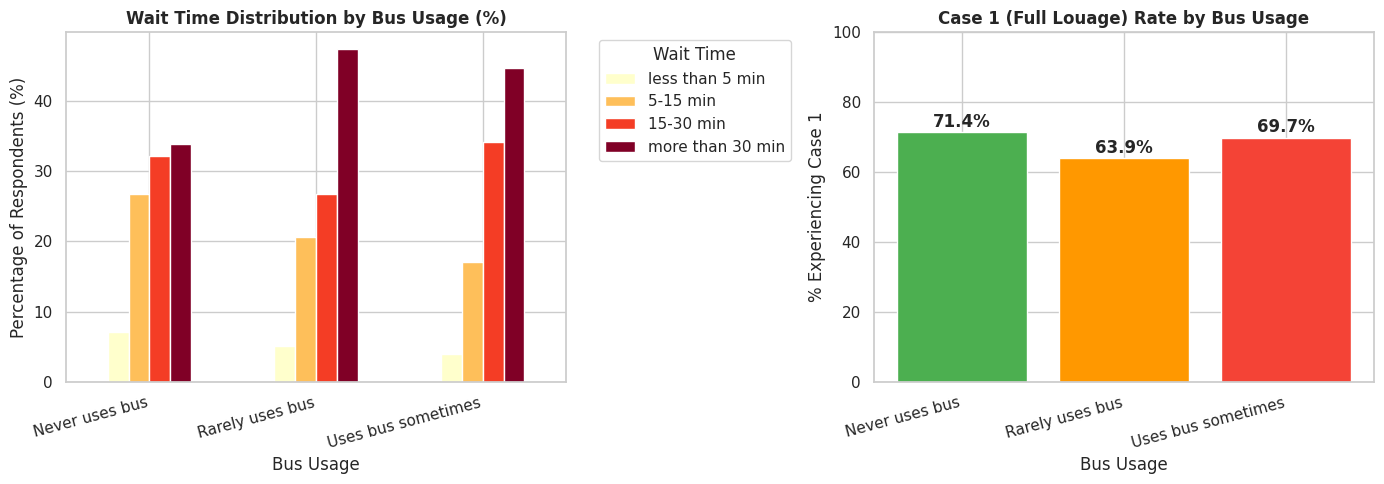

In [31]:
# senario 4: Bus unreliability contribution


bus_map = {
    'نعم أحياناً': 'Uses bus sometimes',
    'نادراً': 'Rarely uses bus',
    'لا  أبداً': 'Never uses bus'
}
df['bus_usage'] = df['use_bus'].map(bus_map)

bus_wait = df.groupby(['bus_usage', 'wait_time']).size().unstack(fill_value=0)
bus_wait_pct = bus_wait.div(bus_wait.sum(axis=1), axis=0) * 100
bus_wait_pct = bus_wait_pct[wait_order]

print("── WAIT TIME DISTRIBUTION BY BUS USAGE ─────────────────")
print(bus_wait_pct.round(1).to_string())

print("\n── CASE 1 RATE BY BUS USAGE ─────────────────────────────")
case1_by_bus = df.groupby('bus_usage')['case_full'].agg(['mean', 'count'])
case1_by_bus.columns = ['Case 1 Rate', 'Count']
case1_by_bus['Case 1 Rate'] = (case1_by_bus['Case 1 Rate'] * 100).round(1)
print(case1_by_bus.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bus_wait_pct.plot(kind='bar', ax=ax1, colormap='YlOrRd',
                  edgecolor='white', legend=True)
ax1.set_title('Wait Time Distribution by Bus Usage (%)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Bus Usage')
ax1.set_ylabel('Percentage of Respondents (%)')
ax1.set_xticklabels(bus_wait_pct.index, rotation=15, ha='right')
ax1.legend(title='Wait Time', bbox_to_anchor=(1.05, 1), loc='upper left')

colors = ['#4CAF50', '#FF9800', '#F44336']
bars = ax2.bar(case1_by_bus.index, case1_by_bus['Case 1 Rate'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, case1_by_bus['Case 1 Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Case 1 (Full Louage) Rate by Bus Usage',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Bus Usage')
ax2.set_ylabel('% Experiencing Case 1')
ax2.set_xticklabels(case1_by_bus.index, rotation=15, ha='right')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('chart11_bus_impact.png', dpi=150, bbox_inches='tight')
plt.show()

***`75% of respondents rarely or never use the bus. Qualitative context reveals that bus usage on this corridor is not a preference but a forced fallback — passengers board the bus only when louage supply fails completely (Case 1 or Case 3). This means bus ridership data on this corridor is a direct proxy for louage service failure frequency, not genuine modal preference. Improving louage supply reliability would reduce forced bus usage, not compete with it.`***

In [33]:
# senarios summary

summary_data = {
    'Scenario': [
        'Worst commute profile',
        'Best commute profile',
        'Time shift: 07h → 12h (KK daily)',
        'Bus as forced fallback',
        'Akouda 07:00-09:00 Case 1 risk',
        'Sousse City — any time slot Case 1 risk',
        'Midday window — KK daily commuter',
    ],
    'Finding': [
        'Akouda, 09:00–11:00, occasional traveller',
        'Kalaa Kebira, 05:00–07:00, daily commuter',
        'Wait drops from >30 min to 5-15 min',
        'Bus used only when louage is full/absent',
        '90% probability of encountering full louage',
        '73–95% Case 1 probability regardless of time',
        'Case 1 risk drops from 60% to 54% only',
    ],
    'Implication': [
        'Pre-position louages at mid-route stops',
        'Early departure significantly reduces wait',
        'Staggered schedules benefit KK commuters',
        'Louage reliability fix reduces forced bus use',
        'Mid-route supply intervention urgently needed',
        'Structural fix needed — not time-based',
        'Time shift alone insufficient — supply fix needed',
    ]
}

summary_df = pd.DataFrame(summary_data)

# Print clean table
print("── SIMULATION SUMMARY ───────────────────────────────────")
for _, row in summary_df.iterrows():
    print(f"\n📌 {row['Scenario']}")
    print(f"   Finding:     {row['Finding']}")
    print(f"   Implication: {row['Implication']}")

# Save as CSV for report
summary_df.to_csv('simulation_summary.csv', index=False)
print("\n\nSaved to simulation_summary.csv ")


── SIMULATION SUMMARY ───────────────────────────────────

📌 Worst commute profile
   Finding:     Akouda, 09:00–11:00, occasional traveller
   Implication: Pre-position louages at mid-route stops

📌 Best commute profile
   Finding:     Kalaa Kebira, 05:00–07:00, daily commuter
   Implication: Early departure significantly reduces wait

📌 Time shift: 07h → 12h (KK daily)
   Finding:     Wait drops from >30 min to 5-15 min
   Implication: Staggered schedules benefit KK commuters

📌 Bus as forced fallback
   Finding:     Bus used only when louage is full/absent
   Implication: Louage reliability fix reduces forced bus use

📌 Akouda 07:00-09:00 Case 1 risk
   Finding:     90% probability of encountering full louage
   Implication: Mid-route supply intervention urgently needed

📌 Sousse City — any time slot Case 1 risk
   Finding:     73–95% Case 1 probability regardless of time
   Implication: Structural fix needed — not time-based

📌 Midday window — KK daily commuter
   Finding:     Case

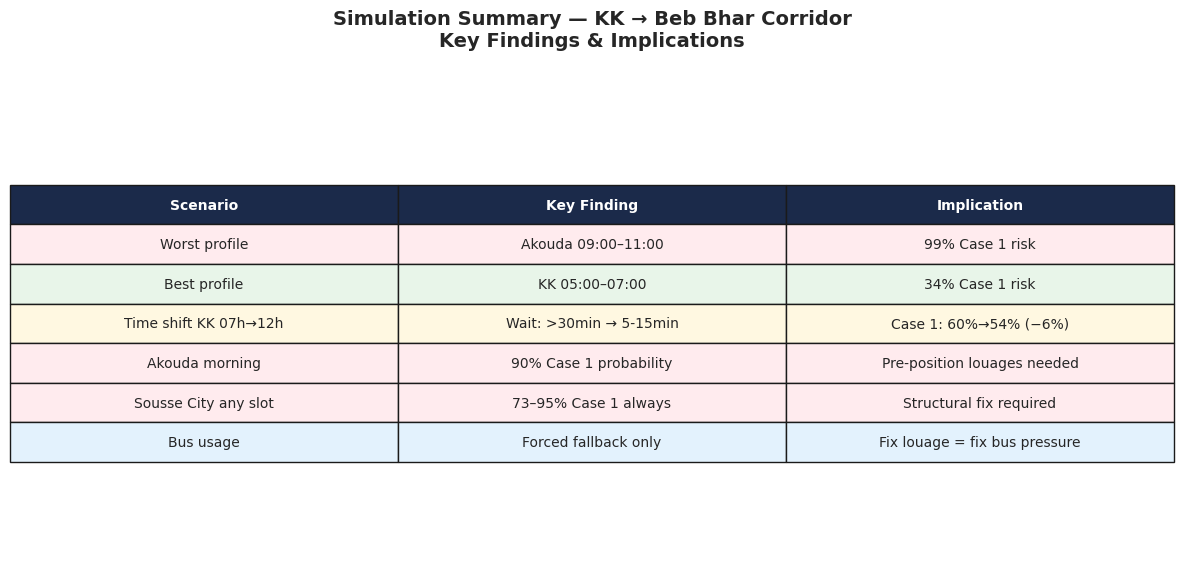

In [34]:
# visualisation for summary

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

table_data = [
    ['Worst profile', 'Akouda 09:00–11:00', '99% Case 1 risk'],
    ['Best profile', 'KK 05:00–07:00', '34% Case 1 risk'],
    ['Time shift KK 07h→12h', 'Wait: >30min → 5-15min', 'Case 1: 60%→54% (−6%)'],
    ['Akouda morning', '90% Case 1 probability', 'Pre-position louages needed'],
    ['Sousse City any slot', '73–95% Case 1 always', 'Structural fix required'],
    ['Bus usage', 'Forced fallback only', 'Fix louage = fix bus pressure'],
]

columns = ['Scenario', 'Key Finding', 'Implication']
colors_rows = [
    ['#FFEBEE', '#FFEBEE', '#FFEBEE'],
    ['#E8F5E9', '#E8F5E9', '#E8F5E9'],
    ['#FFF8E1', '#FFF8E1', '#FFF8E1'],
    ['#FFEBEE', '#FFEBEE', '#FFEBEE'],
    ['#FFEBEE', '#FFEBEE', '#FFEBEE'],
    ['#E3F2FD', '#E3F2FD', '#E3F2FD'],
]

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    cellColours=colors_rows
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for j in range(3):
    table[0, j].set_facecolor('#1B2A4A')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Simulation Summary — KK → Beb Bhar Corridor\nKey Findings & Implications',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart12_simulation_summary.png', dpi=150, bbox_inches='tight')
plt.show()